# 04 GAN：对抗生成网络——原理与训练

> 前置：`probability/07-sampling-monte-carlo`（分布与采样）、`neural-networks/06-optimizers-in-practice`。
> 目标：从博弈论视角理解 GAN 的 min-max 目标；训练一个 2D 高斯混合的 GAN，亲眼观察**模式坍缩（mode collapse）**这一经典困境。

## 核心思想

GAN（Goodfellow, 2014）让两个网络玩一个**二人零和博弈**：

- **生成器 G**：把噪声 z 映射为假样本，目标是骗过判别器；
- **判别器 D**：判断输入是真实样本还是 G 生成的假样本。

$$\min_G \max_D \; \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

**训练不收敛的根源**：这不是最小化一个损失，而是找**纳什均衡**——G 和 D 交替更新，任何一方走得太快都会把对方"训崩"。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 数据与网络

真实分布：两个高斯簇，中心在 (-1,0) 和 (+1,0)，标准差 0.25。生成器把 2D 高斯噪声映射到 2D，输出用 tanh 压到 (-1,1)。

In [2]:
def real_samples(n):
    rng = np.random.default_rng()
    side = rng.integers(0, 2, n)
    return np.stack([np.where(side == 0, -1.0, 1.0) + rng.standard_normal(n) * 0.25,
                     rng.standard_normal(n) * 0.25], axis=1)

torch.manual_seed(0)
G = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 2), nn.Tanh())
D = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 1))
g_opt = torch.optim.Adam(G.parameters(), lr=2e-3)
d_opt = torch.optim.Adam(D.parameters(), lr=2e-3)
print("G 参数量:", sum(p.numel() for p in G.parameters()), " D 参数量:", sum(p.numel() for p in D.parameters()))

G 参数量: 1218  D 参数量: 1185


## 2. 训练循环

交替更新：
1. **更新 D**：真样本给高分（log D(x) 大），假样本给低分（log(1−D(G(z))) 大）；
2. **更新 G**：让 D 对假样本的分数尽可能高（等价于最小化 −log D(G(z))，比 log(1−D) 梯度更好）。

注意 `detach()`：更新 G 时不让梯度穿过 D 的计算图。

In [3]:
g_losses, d_losses = [], []
snapshots = []
for step in range(4000):
    # ---- 更新判别器 D ----
    d_opt.zero_grad()
    real = torch.tensor(real_samples(128), dtype=torch.float32)
    z = torch.randn(128, 2)
    fake = G(z)
    d_real = D(real)
    d_fake = D(fake.detach())
    d_loss = -(torch.log(d_real + 1e-8) + torch.log(1 - d_fake + 1e-8)).mean()
    d_loss.backward(); d_opt.step()
    # ---- 更新生成器 G ----
    g_opt.zero_grad()
    d_fake2 = D(fake)
    g_loss = -torch.log(d_fake2 + 1e-8).mean()
    g_loss.backward(); g_opt.step()
    g_losses.append(g_loss.item()); d_losses.append(d_loss.item())
    if step in (200, 1200, 4000):
        with torch.no_grad():
            snapshots.append((step, G(torch.randn(2000, 2)).numpy()))

print("训练完成")

训练完成


## 3. 可视化：训练动态与模式坍缩

绘制三个时间点的生成分布（绿点 = 真实，橙点 = 生成）。**模式坍缩**：G 发现"只模仿一个峰"就能骗过当前的 D（D 对另一个峰给低分无所谓），于是放弃覆盖第二个峰——这是 GAN 最著名的失败模式。

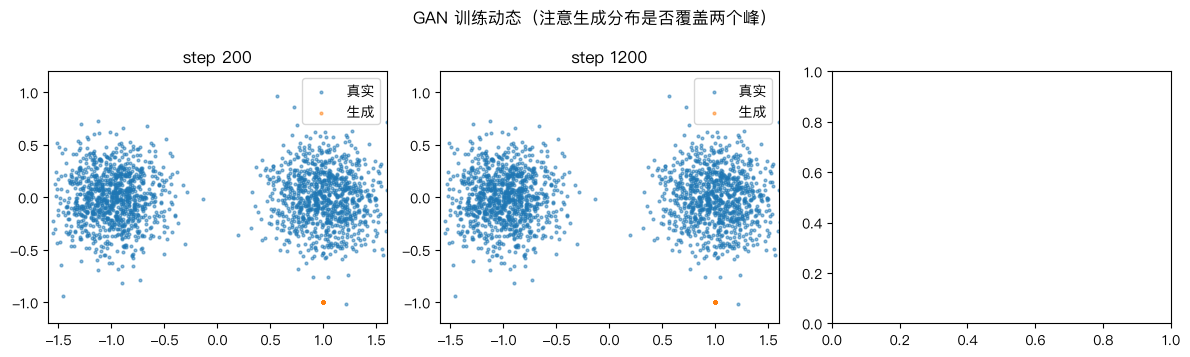

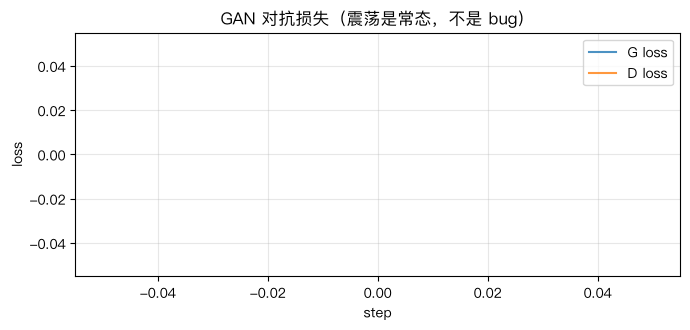

In [4]:
real_pts = real_samples(2000)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (step, pts) in zip(axes, snapshots):
    ax.scatter(real_pts[:, 0], real_pts[:, 1], s=4, alpha=0.5, label="真实")
    ax.scatter(pts[:, 0], pts[:, 1], s=4, alpha=0.5, label="生成")
    ax.set_title(f"step {step}")
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.2, 1.2); ax.legend()
plt.suptitle("GAN 训练动态（注意生成分布是否覆盖两个峰）")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 3.4))
plt.plot(g_losses, label="G loss", alpha=0.8)
plt.plot(d_losses, label="D loss", alpha=0.8)
plt.xlabel("step"); plt.ylabel("loss"); plt.title("GAN 对抗损失（震荡是常态，不是 bug）")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. GAN 家族与后续演进

| 问题 | 改进 | 思想 |
|---|---|---|
| 训练不稳定 | WGAN / WGAN-GP | 用 Wasserstein 距离替代 JS 散度，加梯度惩罚 |
| 模式坍缩 | minibatch discrimination / ProGAN | 让 D 看整批样本统计 |
| 分辨率低 | DCGAN / StyleGAN | 卷积架构 + 风格控制（StyleGAN 至今仍是最强人脸生成器之一） |
| 模式坍缩根治 | Diffusion | 换个赛道：不再对抗，而是"学习逐步去噪"（见 06 课） |

**教训**：GAN 把"隐式分布匹配"做成博弈，灵活但难训；现代生成（扩散、流模型）用**显式去噪目标**换来稳定，代价是采样慢。这是生成式 AI 最重要的一次范式转移。

## 课后练习

1. 把学习率从 2e-3 改成 5e-3，观察损失震荡和生成质量——体会"D/G 步调要匹配"。
2. 把两个高斯簇中心从 ±1.0 拉开到 ±2.0，观察模式坍缩是否更严重（簇越远，覆盖两个簇的中间区域越"浪费"）。
3. 把 G 的最后一层 tanh 去掉（输出无界），观察训练稳定性变化。